In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install mlflow dagshub -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 79.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 77.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import mlflow
import os


DAGSHUB_USERNAME = "aleko-mamukashvili"
DAGSHUB_REPO = "-IEEE-CIS-Fraud-Detection."
DAGSHUB_TOKEN = "d6c5e757686d92fdb2ebb1475f4fdfa58b901810"

os.environ["MLFLOW_TRACKING_URI"] = f"https://dagshub.com/{DAGSHUB_USERNAME}/{DAGSHUB_REPO}.mlflow"
os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
os.environ["MLFLOW_TRACKING_PASSWORD"] = DAGSHUB_TOKEN

mlflow.set_tracking_uri(os.environ['MLFLOW_TRACKING_URI'])

In [4]:
import pandas as pd
import numpy as np
import gc

def reduce_mem_usage(df):
    """ ფუნქცია, რომელიც ამცირებს მონაცემების მიერ დაკავებულ ადგილს RAM-ში """
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Mem usage decreased to {end_mem:.2f} Mb')
    return df

# ფაილების რეალური წაკითხვა (pd.read_csv-ს გარეშე merge არ იმუშავებს)
print("Loading data...")
train_transaction_df = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
train_identity_df = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')

# გაერთიანება
print("Merging data...")
train = pd.merge(train_transaction_df, train_identity_df, on='TransactionID', how='left')

# მეხსიერების ოპტიმიზაცია
train = reduce_mem_usage(train)

# დროებითი ცხრილების წაშლა RAM-ის გამოსათავისუფლებლად
del train_transaction_df, train_identity_df
gc.collect()

print(f"✅ მონაცემები მზად არის. ზომა: {train.shape}")

Loading data...
Merging data...


/tmp/ipykernel_57/1551422315.py:23: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/1551422315.py:23: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/1551422315.py:23: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/1551422315.py:23: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/1551422315.py:23: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/1551422315.py:23: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/1551422315.py:23: RuntimeWarning: overfl

Mem usage decreased to 645.97 Mb
✅ მონაცემები მზად არის. ზომა: (590540, 434)


In [5]:
import mlflow

mlflow.set_experiment("IEEE_Fraud_Cleaning")

with mlflow.start_run(run_name="Drop_High_Missing_Values"):
    missing_threshold = 0.90
    null_cols = [c for c in train.columns if train[c].isnull().sum() / train.shape[0] > missing_threshold]
    
    mlflow.log_param("missing_threshold", missing_threshold)
    mlflow.log_param("total_columns_before", train.shape[1])
    mlflow.log_param("dropped_columns_count", len(null_cols))
    
    train = train.drop(columns=null_cols)
    
    mlflow.log_metric("remaining_columns", train.shape[1])
    
    print(f"Dropped: {len(null_cols)}")
    print(f"Remaining: {train.shape[1]}")

2026/05/06 15:04:42 INFO mlflow.tracking.fluent: Experiment with name 'IEEE_Fraud_Cleaning' does not exist. Creating a new experiment.


Dropped: 12
Remaining: 422


In [9]:
with mlflow.start_run(run_name="Feature_Engineering_Basic"):
    
    train['TransactionAmt_Log'] = np.log(train['TransactionAmt'])
    
    train['tm_hour'] = (train['TransactionDT'] // (3600)) % 24
    train['tm_day_no'] = (train['TransactionDT'] // (3600 * 24)) % 7
    
    emails = {'gmail': 'google', 'att.net': 'att', 'twc.com': 'spectrum', 
              'sc.rr.com': 'spectrum', 'nycap.rr.com': 'spectrum', 
              'outlook.com': 'microsoft', 'msn.com': 'microsoft', 'live.com.mx': 'microsoft', 
              'hotmail.es': 'microsoft', 'hotmail.com': 'microsoft', 'hotmail.de': 'microsoft', 
              'hotmail.it': 'microsoft', 'hotmail.fr': 'microsoft', 'live.com': 'microsoft', 
              'icloud.com': 'apple'}
    
    for c in ['P_emaildomain', 'R_emaildomain']:
        train[c + '_bin'] = train[c].map(emails)
        
    mlflow.log_param("added_features", ["TransactionAmt_Log", "tm_hour", "tm_day_no", "email_bin"])
    mlflow.log_metric("features_after_eng", train.shape[1])
    
    print(f"New features added. Total columns: {train.shape[1]}")

/tmp/ipykernel_57/2511029758.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['TransactionAmt_Log'] = np.log(train['TransactionAmt'])
/tmp/ipykernel_57/2511029758.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['tm_hour'] = (train['TransactionDT'] // (3600)) % 24
/tmp/ipykernel_57/2511029758.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.

New features added. Total columns: 427
🏃 View run Feature_Engineering_Basic at: https://dagshub.com/aleko-mamukashvili/-IEEE-CIS-Fraud-Detection..mlflow/#/experiments/4/runs/3638f1d0d3e74e61a423883f5b4f5a51
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/-IEEE-CIS-Fraud-Detection..mlflow/#/experiments/4


In [10]:
from sklearn.preprocessing import LabelEncoder

train = train.copy()

with mlflow.start_run(run_name="Categorical_Encoding"):
    
    cat_cols = [c for c in train.columns if train[c].dtype == 'object']
    
    for col in cat_cols:
        le = LabelEncoder()
        train[col] = le.fit_transform(train[col].astype(str))
    
    mlflow.log_param("encoded_columns_count", len(cat_cols))
    mlflow.log_metric("final_feature_count", train.shape[1])
    
    print(f"Encoded {len(cat_cols)} columns.")
    print(f"Final shape: {train.shape}")

Encoded 31 columns.
Final shape: (590540, 427)
🏃 View run Categorical_Encoding at: https://dagshub.com/aleko-mamukashvili/-IEEE-CIS-Fraud-Detection..mlflow/#/experiments/4/runs/f3394a17a37a469aa7ab4174c2614f3c
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/-IEEE-CIS-Fraud-Detection..mlflow/#/experiments/4


/tmp/ipykernel_57/4117346914.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='isFraud', data=train, palette='viridis')


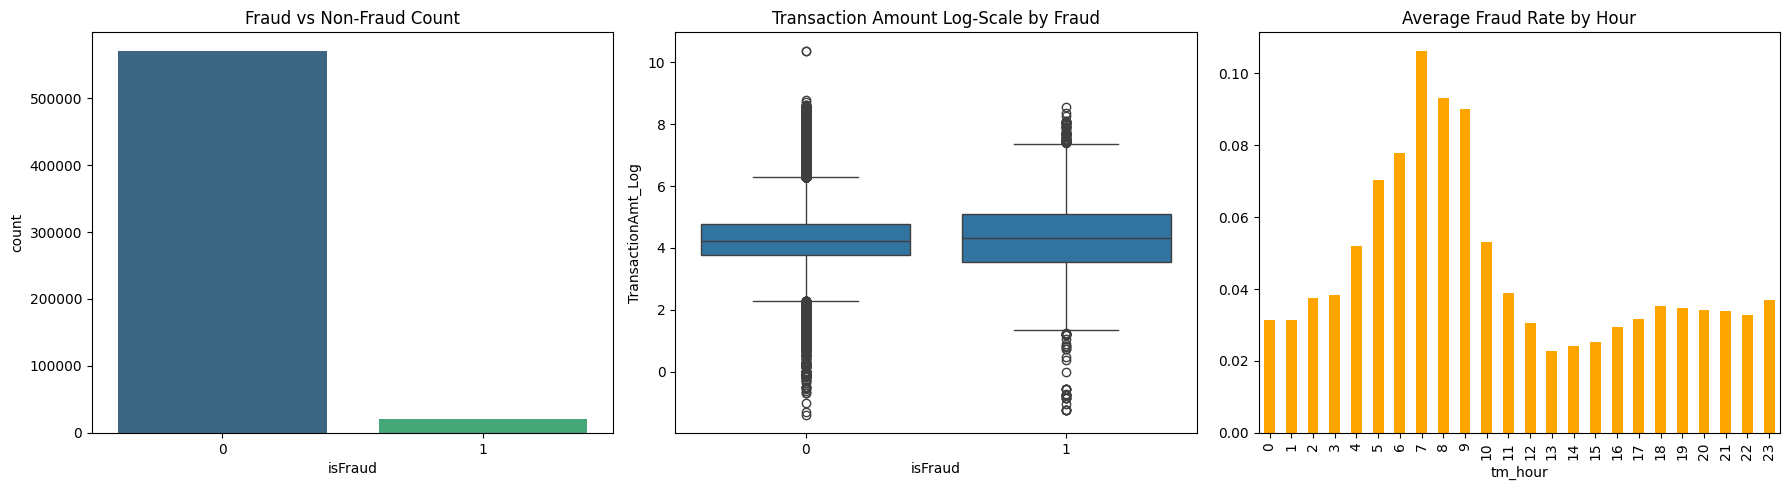

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 5))

# 1. თაღლითობის განაწილება (Imbalance)
plt.subplot(1, 3, 1)
sns.countplot(x='isFraud', data=train, palette='viridis')
plt.title('Fraud vs Non-Fraud Count')

# 2. ტრანზაქციის თანხის განაწილება (ლოგარითმული მასშტაბით უკეთ ჩანს)
plt.subplot(1, 3, 2)
sns.boxplot(x='isFraud', y='TransactionAmt_Log', data=train)
plt.title('Transaction Amount Log-Scale by Fraud')

# 3. საათობრივი აქტივობა
plt.subplot(1, 3, 3)
train.groupby('tm_hour')['isFraud'].mean().plot(kind='bar', color='orange')
plt.title('Average Fraud Rate by Hour')

plt.tight_layout()
plt.show()

/tmp/ipykernel_57/1533252319.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_corr.values, y=top_20_corr.index, palette='coolwarm')


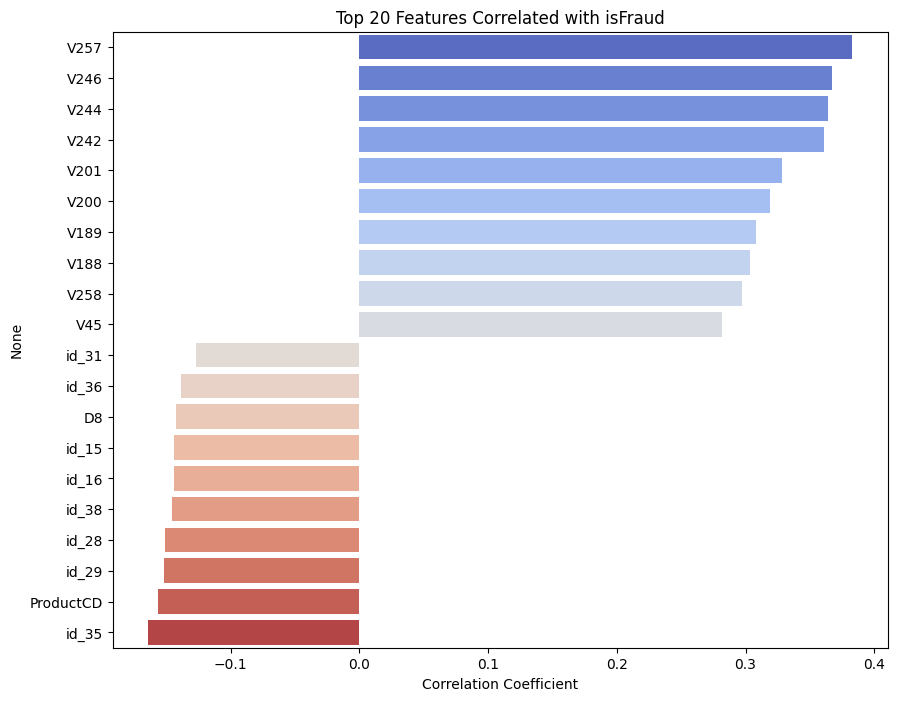

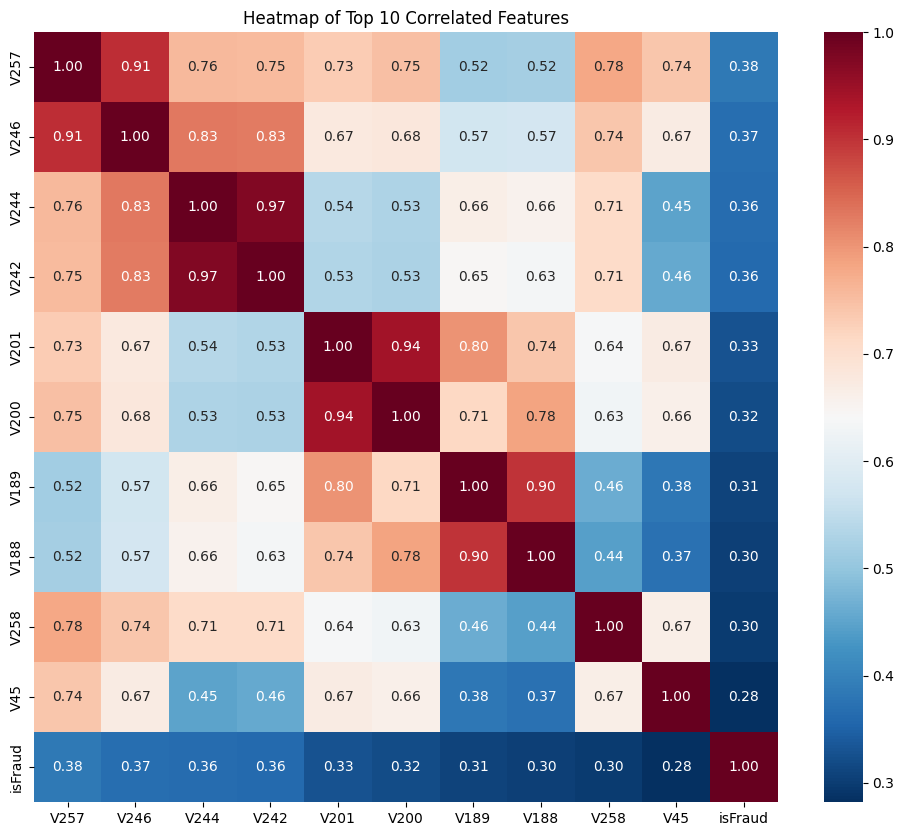

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# კორელაციების გამოთვლა
correlations = train.corr()['isFraud'].drop('isFraud').sort_values(ascending=False)

top_20_corr = pd.concat([correlations.head(10), correlations.tail(10)])

plt.figure(figsize=(10, 8))
sns.barplot(x=top_20_corr.values, y=top_20_corr.index, palette='coolwarm')
plt.title('Top 20 Features Correlated with isFraud')
plt.xlabel('Correlation Coefficient')
plt.show()

# Heatmap ტოპ 10 სვეტისთვის
top_features = correlations.abs().sort_values(ascending=False).head(10).index
plt.figure(figsize=(12, 10))
sns.heatmap(train[list(top_features) + ['isFraud']].corr(), annot=True, cmap='RdBu_r', fmt='.2f')
plt.title('Heatmap of Top 10 Correlated Features')
plt.show()

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
import mlflow

mlflow.set_experiment("Logistic_Regression_Experiment")

X = train.drop(['isFraud', 'TransactionID', 'TransactionDT'], axis=1)
y = train['isFraud']
X = X.fillna(-1)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

with mlflow.start_run(run_name="LR_Final_Training"):
    lr = LogisticRegression(max_iter=500, solver='liblinear', random_state=42)
    lr.fit(X_train_scaled, y_train)
    
    y_pred = lr.predict_proba(X_val_scaled)[:, 1]
    auc_score = roc_auc_score(y_val, y_pred)
    
    mlflow.log_param("model_type", "Logistic_Regression")
    mlflow.log_param("max_iter", 500)
    mlflow.log_metric("auc_roc", auc_score)
    
    print(f"Training Complete.")
    print(f"Validation AUC: {auc_score:.4f}")

2026/05/06 15:03:51 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/06 15:03:51 INFO mlflow.store.db.utils: Updating database tables
2026/05/06 15:03:54 INFO mlflow.tracking.fluent: Experiment with name 'Logistic_Regression_Experiment' does not exist. Creating a new experiment.


NameError: name 'train' is not defined